In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('ford.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [3]:
df.shape

(17966, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [5]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [6]:
df = df[df['year'] != 2060]

In [7]:
df['model'] = df['model'].str.strip()

In [8]:
df.isna().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

<Axes: xlabel='price', ylabel='Count'>

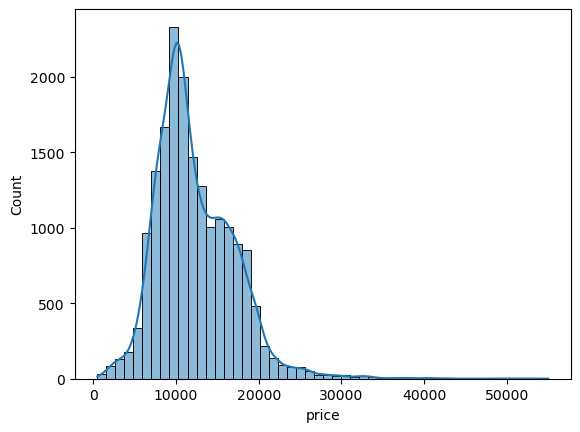

In [9]:
## EDA

sns.histplot(df['price'], bins=50, kde=True)

<Axes: >

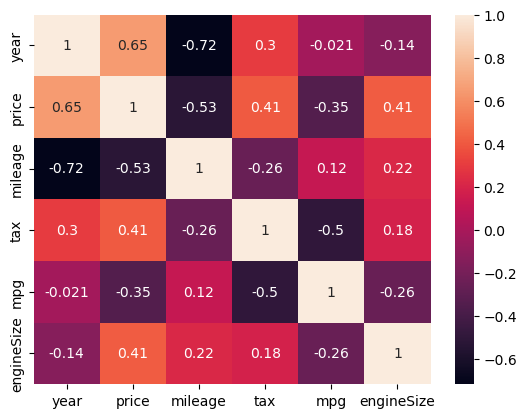

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

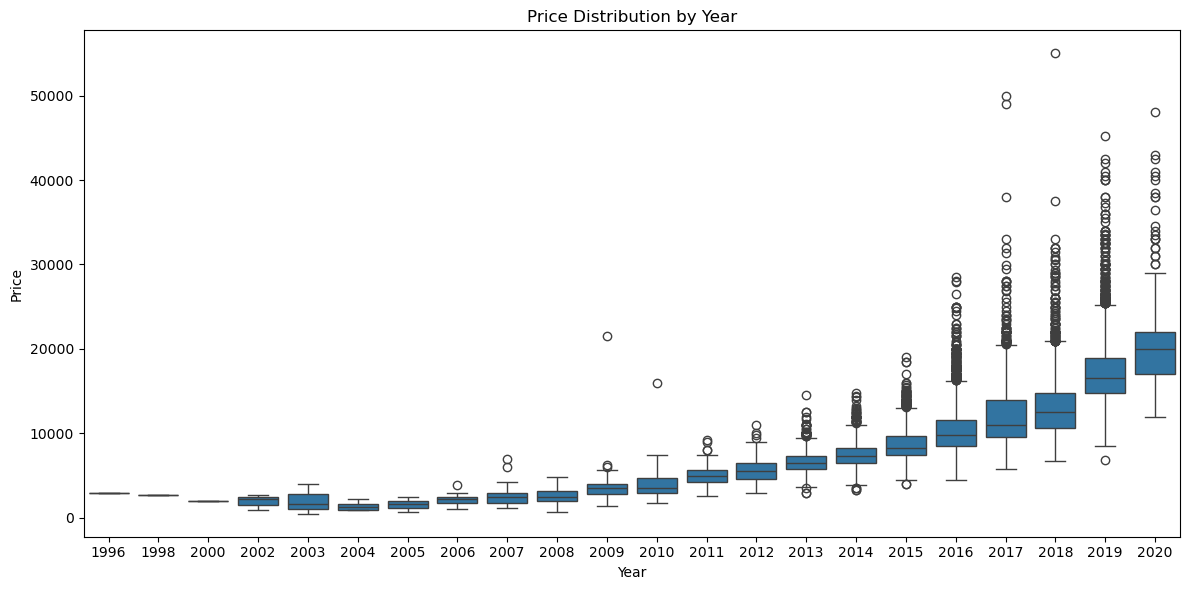

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='year', y='price')
plt.title('Price Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.tight_layout()

<Axes: xlabel='mileage', ylabel='price'>

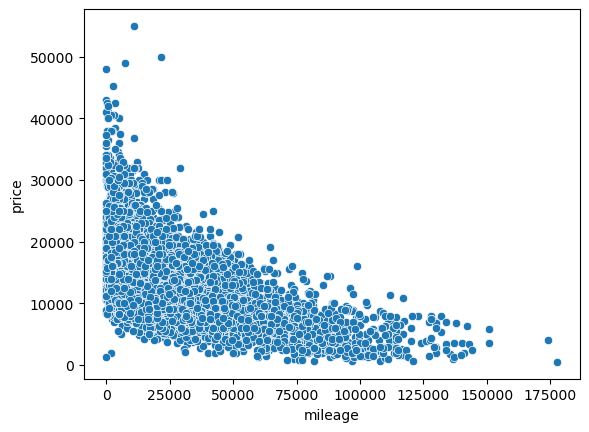

In [12]:
sns.scatterplot(data=df, x='mileage', y='price')

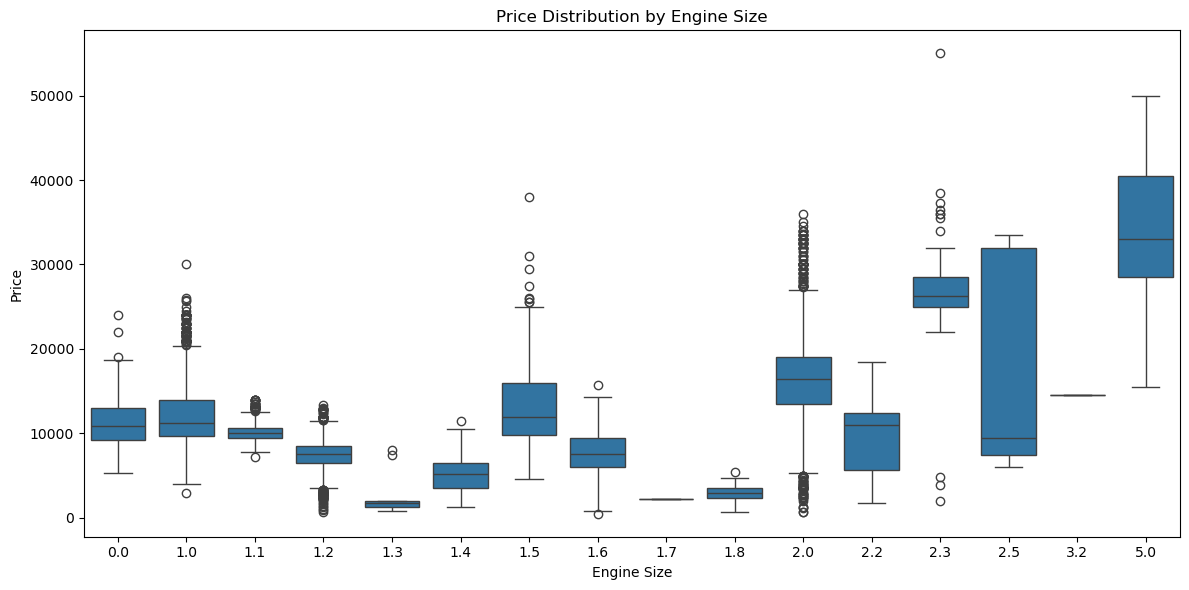

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='engineSize', y='price')
plt.title('Price Distribution by Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.tight_layout()

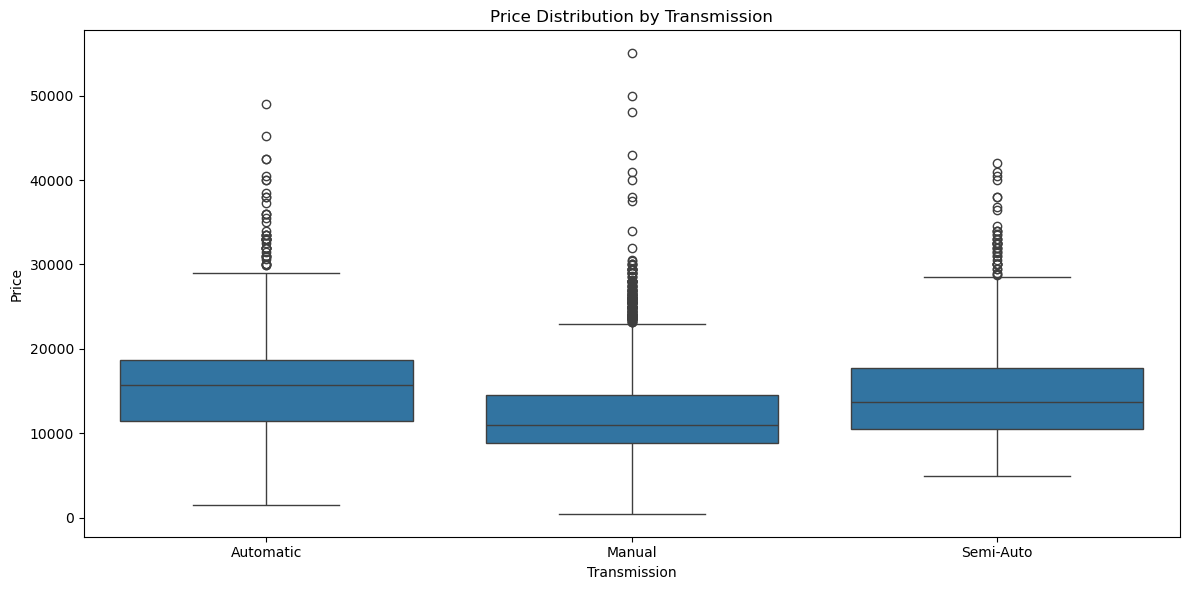

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='transmission', y='price')
plt.title('Price Distribution by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.tight_layout()

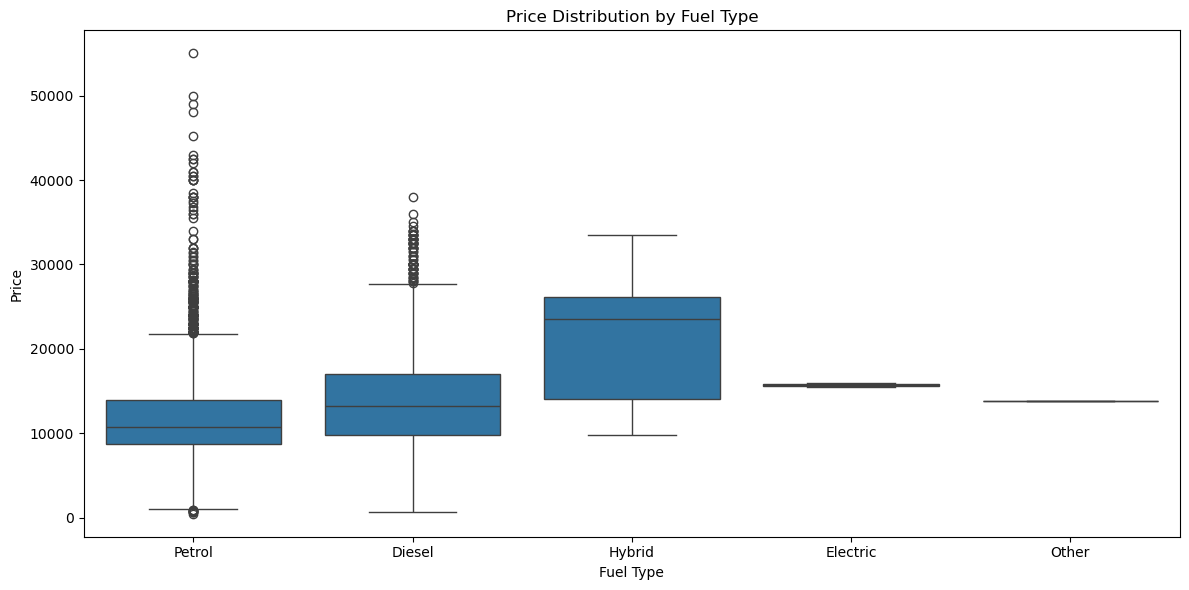

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='fuelType', y='price')
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.tight_layout()

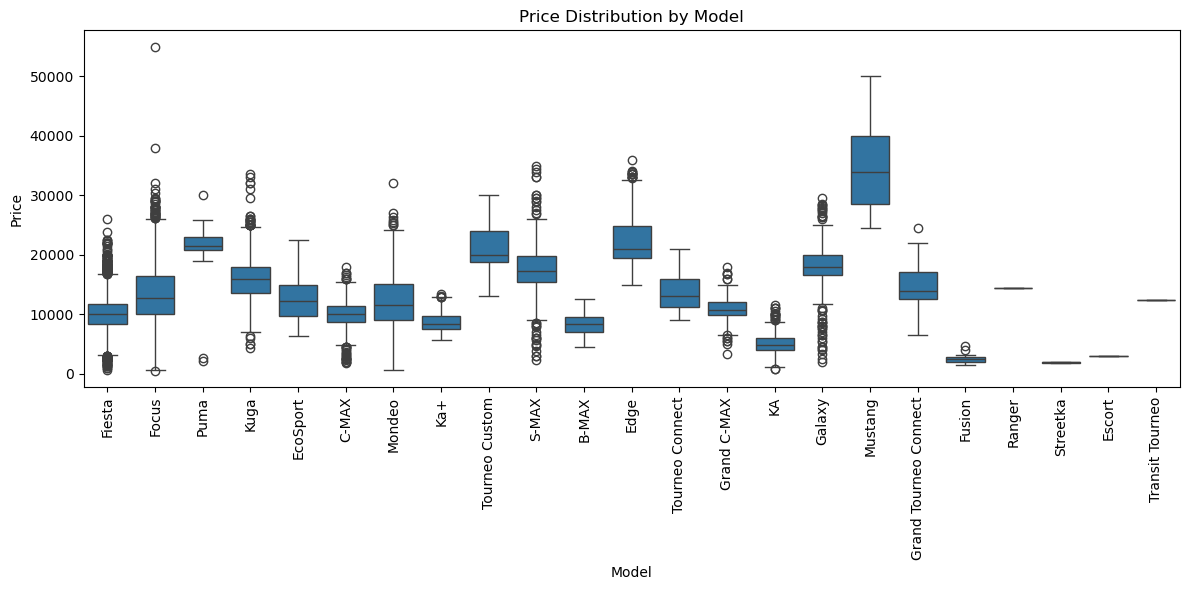

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='model', y='price')
plt.xticks(rotation = 90)
plt.title('Price Distribution by Model')
plt.xlabel('Model')
plt.ylabel('Price')
plt.tight_layout()

In [17]:
from scipy import stats
corr, pvalue = stats.pearsonr(df['tax'], df['price'])
print(f"Correlation: {corr:.4f} | P-value: {pvalue:.4f}")

Correlation: 0.4070 | P-value: 0.0000


<Axes: xlabel='tax', ylabel='price'>

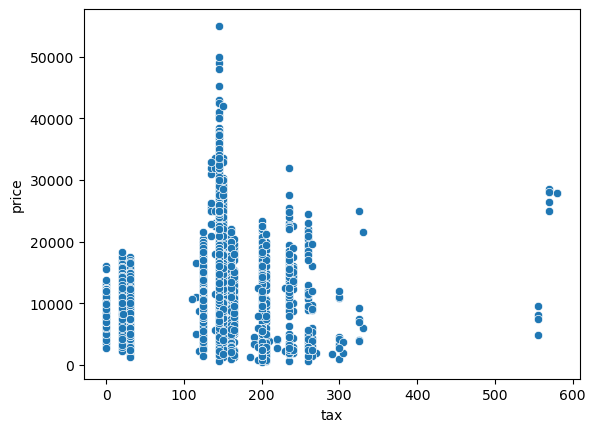

In [18]:
sns.scatterplot(data=df, x='tax', y='price')

In [19]:
df['tax'].value_counts().sort_index()

tax
0      2153
20     1210
22        1
30     1236
110       1
115       3
120       2
125    1407
135      10
140       8
145    8944
150    1944
155       3
160     358
165     113
185       1
190       2
195       6
200     252
205      59
210       1
220       3
230       2
235     123
240      32
260      41
265      15
270       1
290       1
300      11
305       2
325       6
330       2
555       4
570       6
580       2
Name: count, dtype: int64

In [20]:
df['tax_category'] = pd.cut(df['tax'],
    bins=[-1, 0, 30, 165, 270, 600],
    labels=['Zero', 'Very Low', 'Medium',
            'High', 'Very High'])
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,tax_category
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,Medium
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0,Medium
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0,Medium
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5,Medium
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0,Medium


<Axes: xlabel='tax_category', ylabel='price'>

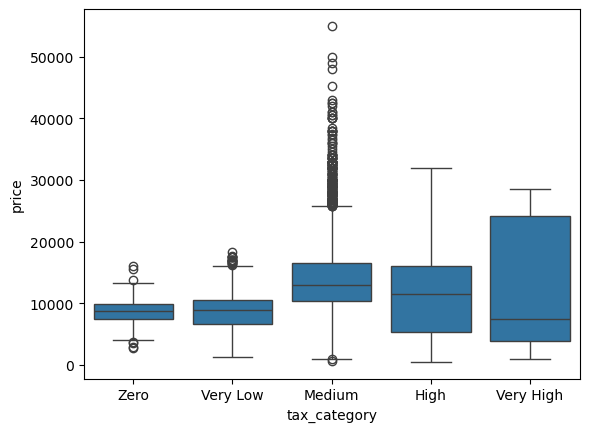

In [21]:
sns.boxplot(data=df, x='tax_category', y='price')

In [22]:
df.drop('tax', axis=1, inplace=True)
df.head()

,model,year,price,transmission,mileage,fuelType,mpg,engineSize,tax_category
0,Fiesta,2017,12000,Automatic,15944,Petrol,57.7,1.0,Medium
1,Focus,2018,14000,Manual,9083,Petrol,57.7,1.0,Medium
2,Focus,2017,13000,Manual,12456,Petrol,57.7,1.0,Medium
3,Fiesta,2019,17500,Manual,10460,Petrol,40.3,1.5,Medium
4,Fiesta,2019,16500,Automatic,1482,Petrol,48.7,1.0,Medium


In [23]:
from scipy import stats
corr, pvalue = stats.pearsonr(df['mpg'], df['price'])
print(f"Correlation: {corr:.4f} | P-value: {pvalue:.4f}")

Correlation: -0.3466 | P-value: 0.0000


<Axes: xlabel='mpg', ylabel='price'>

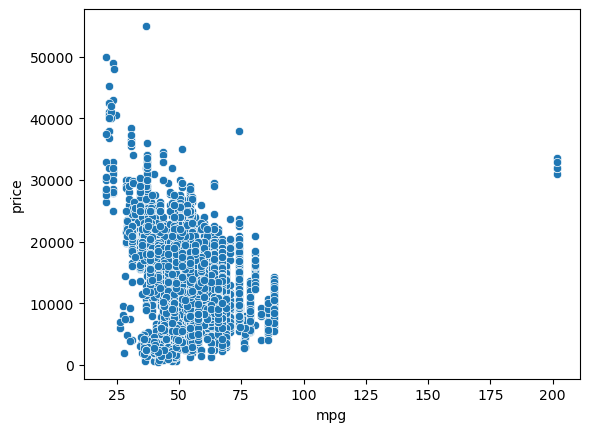

In [24]:
sns.scatterplot(data=df, x='mpg', y='price')

In [25]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'mpg',
       'engineSize', 'tax_category'],
      dtype='str')

In [26]:
df['year'].value_counts()

year
2017    4888
2018    4014
2019    3194
2016    2331
2015    1368
2014     805
2013     609
2020     258
2012     115
2011      94
2009      91
2010      67
2008      57
2007      32
2005      16
2006      13
2004       4
2002       3
2003       3
1998       1
1996       1
2000       1
Name: count, dtype: int64

In [27]:
groups = [df[df['transmission'] == t]['price']
          for t in df['transmission'].unique()]

fstat, pvalue = stats.f_oneway(*groups)
print(f"P-value: {pvalue:.4f}")

P-value: 0.0000


In [28]:
groups = [df[df['model'] == t]['price']
          for t in df['model'].unique()]

fstat, pvalue = stats.f_oneway(*groups)
print(f"P-value: {pvalue:.4f}")

P-value: 0.0000


In [29]:
groups = [df[df['fuelType'] == t]['price']
          for t in df['fuelType'].unique()]

fstat, pvalue = stats.f_oneway(*groups)
print(f"P-value: {pvalue:.4f}")

P-value: 0.0000


In [30]:
x = df.drop('price', axis=1)
y = df['price']
x.head()

,model,year,transmission,mileage,fuelType,mpg,engineSize,tax_category
0,Fiesta,2017,Automatic,15944,Petrol,57.7,1.0,Medium
1,Focus,2018,Manual,9083,Petrol,57.7,1.0,Medium
2,Focus,2017,Manual,12456,Petrol,57.7,1.0,Medium
3,Fiesta,2019,Manual,10460,Petrol,40.3,1.5,Medium
4,Fiesta,2019,Automatic,1482,Petrol,48.7,1.0,Medium


In [31]:
x['model'].value_counts()

model
Fiesta                   6556
Focus                    4589
Kuga                     2225
EcoSport                 1143
C-MAX                     543
Ka+                       531
Mondeo                    526
B-MAX                     355
S-MAX                     296
Grand C-MAX               247
Galaxy                    228
Edge                      208
KA                        199
Puma                       80
Tourneo Custom             69
Grand Tourneo Connect      59
Mustang                    57
Tourneo Connect            33
Fusion                     16
Streetka                    2
Ranger                      1
Escort                      1
Transit Tourneo             1
Name: count, dtype: int64

In [32]:
x['transmission'].value_counts()

transmission
Manual       15518
Automatic     1360
Semi-Auto     1087
Name: count, dtype: int64

In [33]:
x['fuelType'].value_counts()

fuelType
Petrol      12178
Diesel       5762
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

In [34]:
model_counts = x['model'].value_counts()
rare_models  = model_counts[
               model_counts < 50]
rare_models_index = rare_models.index

In [35]:
rare_models_index

Index(['Tourneo Connect', 'Fusion', 'Streetka', 'Ranger', 'Escort',
       'Transit Tourneo'],
      dtype='str', name='model')

In [36]:
rare_models

model
Tourneo Connect    33
Fusion             16
Streetka            2
Ranger              1
Escort              1
Transit Tourneo     1
Name: count, dtype: int64

In [37]:
x['model'] = x['model'].replace(
              rare_models_index, 'Other')
x['model'].value_counts()

model
Fiesta                   6556
Focus                    4589
Kuga                     2225
EcoSport                 1143
C-MAX                     543
Ka+                       531
Mondeo                    526
B-MAX                     355
S-MAX                     296
Grand C-MAX               247
Galaxy                    228
Edge                      208
KA                        199
Puma                       80
Tourneo Custom             69
Grand Tourneo Connect      59
Mustang                    57
Other                      54
Name: count, dtype: int64

In [38]:
x = pd.get_dummies(x,
    columns=['model'],
    drop_first=True)
x.head()

,year,transmission,mileage,fuelType,mpg,engineSize,tax_category,model_C-MAX,model_EcoSport,model_Edge,...,model_Grand Tourneo Connect,model_KA,model_Ka+,model_Kuga,model_Mondeo,model_Mustang,model_Other,model_Puma,model_S-MAX,model_Tourneo Custom
0,2017,Automatic,15944,Petrol,57.7,1.0,Medium,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2018,Manual,9083,Petrol,57.7,1.0,Medium,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2017,Manual,12456,Petrol,57.7,1.0,Medium,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2019,Manual,10460,Petrol,40.3,1.5,Medium,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2019,Automatic,1482,Petrol,48.7,1.0,Medium,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [39]:
x = pd.get_dummies(x,
        columns=['transmission'],
        drop_first=True)

In [40]:
x.head()

,year,mileage,fuelType,mpg,engineSize,tax_category,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,...,model_Ka+,model_Kuga,model_Mondeo,model_Mustang,model_Other,model_Puma,model_S-MAX,model_Tourneo Custom,transmission_Manual,transmission_Semi-Auto
0,2017,15944,Petrol,57.7,1.0,Medium,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,2018,9083,Petrol,57.7,1.0,Medium,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2017,12456,Petrol,57.7,1.0,Medium,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,2019,10460,Petrol,40.3,1.5,Medium,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,2019,1482,Petrol,48.7,1.0,Medium,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [41]:
fuel_counts = x['fuelType'].value_counts()
rare_fuels  = fuel_counts[
              fuel_counts < 50].index

x['fuelType'] = x['fuelType'].replace(
                 rare_fuels, 'Other')
x['fuelType'].value_counts()

fuelType
Petrol    12178
Diesel     5762
Other        25
Name: count, dtype: int64

In [42]:
x = pd.get_dummies(x,
        columns=['fuelType'],
        drop_first=True)

In [43]:
x.head()

,year,mileage,mpg,engineSize,tax_category,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,model_Focus,...,model_Mondeo,model_Mustang,model_Other,model_Puma,model_S-MAX,model_Tourneo Custom,transmission_Manual,transmission_Semi-Auto,fuelType_Other,fuelType_Petrol
0,2017,15944,57.7,1.0,Medium,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,57.7,1.0,Medium,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
2,2017,12456,57.7,1.0,Medium,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,2019,10460,40.3,1.5,Medium,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
4,2019,1482,48.7,1.0,Medium,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [44]:
x['tax_category'].value_counts()

tax_category
Medium       12793
Very Low      2447
Zero          2153
High           538
Very High       34
Name: count, dtype: int64

In [45]:
groups = [df[df['tax_category'] == t]['price']
          for t in df['tax_category'].unique()]

fstat, pvalue = stats.f_oneway(*groups)
print(f"P-value: {pvalue:.4f}")

P-value: 0.0000


In [46]:
x = pd.get_dummies(x,
        columns=['tax_category'],
        drop_first=True)
x.head()

,year,mileage,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,model_Focus,model_Galaxy,...,model_S-MAX,model_Tourneo Custom,transmission_Manual,transmission_Semi-Auto,fuelType_Other,fuelType_Petrol,tax_category_Very Low,tax_category_Medium,tax_category_High,tax_category_Very High
0,2017,15944,57.7,1.0,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
1,2018,9083,57.7,1.0,False,False,False,False,True,False,...,False,False,True,False,False,True,False,True,False,False
2,2017,12456,57.7,1.0,False,False,False,False,True,False,...,False,False,True,False,False,True,False,True,False,False
3,2019,10460,40.3,1.5,False,False,False,True,False,False,...,False,False,True,False,False,True,False,True,False,False
4,2019,1482,48.7,1.0,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False


In [47]:
x = x.astype('float32')
x.head()

,year,mileage,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,model_Focus,model_Galaxy,...,model_S-MAX,model_Tourneo Custom,transmission_Manual,transmission_Semi-Auto,fuelType_Other,fuelType_Petrol,tax_category_Very Low,tax_category_Medium,tax_category_High,tax_category_Very High
0,2017.0,15944.0,57.700001,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,2018.0,9083.0,57.700001,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,2017.0,12456.0,57.700001,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,2019.0,10460.0,40.299999,1.5,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,2019.0,1482.0,48.700001,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [48]:
x.dtypes

year                           float32
mileage                        float32
mpg                            float32
engineSize                     float32
model_C-MAX                    float32
model_EcoSport                 float32
model_Edge                     float32
model_Fiesta                   float32
model_Focus                    float32
model_Galaxy                   float32
model_Grand C-MAX              float32
model_Grand Tourneo Connect    float32
model_KA                       float32
model_Ka+                      float32
model_Kuga                     float32
model_Mondeo                   float32
model_Mustang                  float32
model_Other                    float32
model_Puma                     float32
model_S-MAX                    float32
model_Tourneo Custom           float32
transmission_Manual            float32
transmission_Semi-Auto         float32
fuelType_Other                 float32
fuelType_Petrol                float32
tax_category_Very Low    

In [49]:
x['year'] = x['year'].astype('int32')
x['mileage'] = x['mileage'].astype('int32')

In [50]:
x.head()

,year,mileage,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,model_Focus,model_Galaxy,...,model_S-MAX,model_Tourneo Custom,transmission_Manual,transmission_Semi-Auto,fuelType_Other,fuelType_Petrol,tax_category_Very Low,tax_category_Medium,tax_category_High,tax_category_Very High
0,2017,15944,57.700001,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,2018,9083,57.700001,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,2017,12456,57.700001,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,2019,10460,40.299999,1.5,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,2019,1482,48.700001,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [51]:
x.dtypes

year                             int32
mileage                          int32
mpg                            float32
engineSize                     float32
model_C-MAX                    float32
model_EcoSport                 float32
model_Edge                     float32
model_Fiesta                   float32
model_Focus                    float32
model_Galaxy                   float32
model_Grand C-MAX              float32
model_Grand Tourneo Connect    float32
model_KA                       float32
model_Ka+                      float32
model_Kuga                     float32
model_Mondeo                   float32
model_Mustang                  float32
model_Other                    float32
model_Puma                     float32
model_S-MAX                    float32
model_Tourneo Custom           float32
transmission_Manual            float32
transmission_Semi-Auto         float32
fuelType_Other                 float32
fuelType_Petrol                float32
tax_category_Very Low    

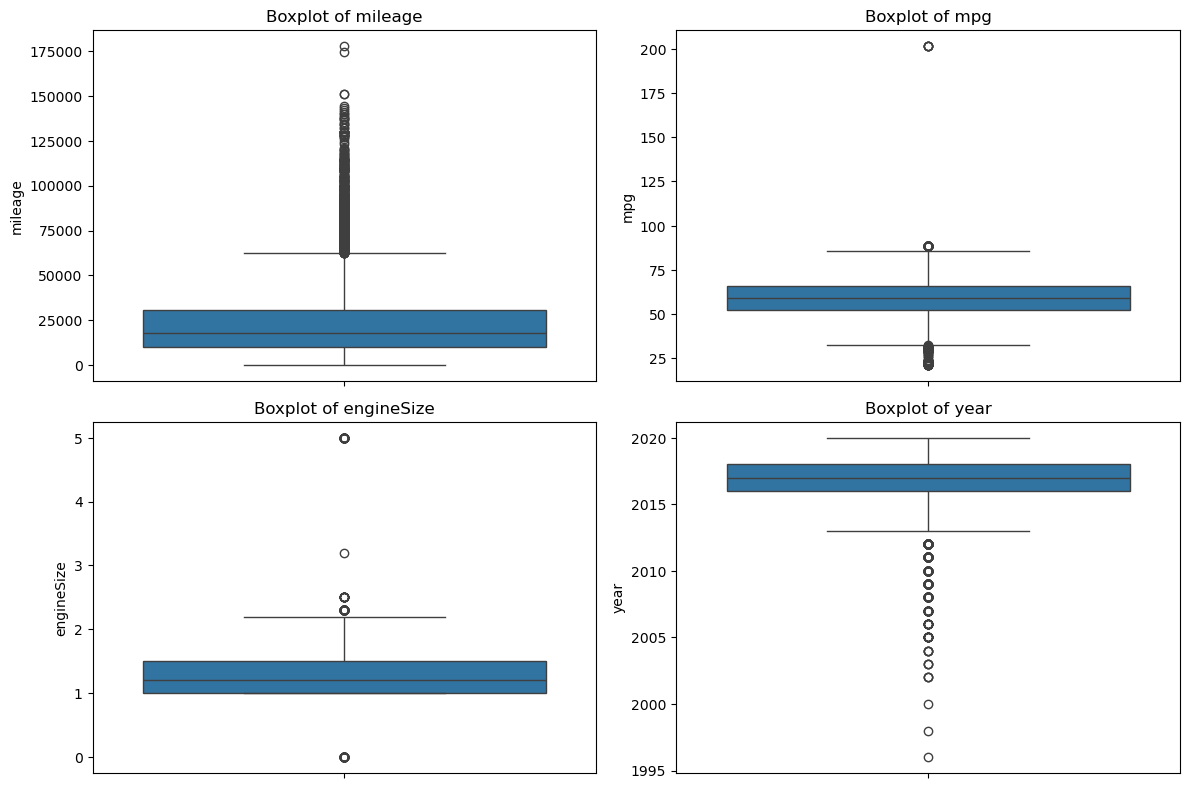

In [52]:
# Define columns to plot
cols = ['mileage', 'mpg', 
        'engineSize', 'year']

# Create subplots
fig, axes = plt.subplots(
    nrows=2, ncols=2,    # 2 rows 2 cols
    figsize=(12, 8))     # overall size

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each column
for i, col in enumerate(cols):
    sns.boxplot(data=x, 
                y=col, 
                ax=axes[i])  # place in correct subplot
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [54]:
X_train.head()

,year,mileage,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,model_Fiesta,model_Focus,model_Galaxy,...,model_S-MAX,model_Tourneo Custom,transmission_Manual,transmission_Semi-Auto,fuelType_Other,fuelType_Petrol,tax_category_Very Low,tax_category_Medium,tax_category_High,tax_category_Very High
4032,2020,10,55.400002,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
16054,2015,58199,64.199997,1.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
17266,2011,73780,40.900002,1.6,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
15479,2016,17050,54.299999,1.2,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1575,2018,19653,41.500000,2.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
y_pred = model.predict(x_test_scaled)
y_pred

array([16507.04303904,  9209.93117442,  9684.55542603, ...,
       11797.90488358, 28738.03619401,  9599.38575323])

In [58]:
y_test.values

array([12495,  8999,  7998, ..., 13699, 24979, 10500], dtype=int64)

In [59]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
n = x_test_scaled.shape[0]
p = x_test_scaled.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("TESTING RESULTS:")
print(f"R²          : {r2:.4f}")
print(f"Adjusted R² : {adjusted_r2:.4f}")

TESTING RESULTS:
R²          : 0.8485
Adjusted R² : 0.8472


In [60]:
y_train_pred = model.predict(x_train_scaled)
y_train_pred

array([15253.71361948,  7404.67186048,  4040.49734881, ...,
       14089.61275584, 16057.73288545, 10669.83922787])

In [61]:
y_train.values

array([19718,  9499,  5485, ..., 11950, 15998,  9700], dtype=int64)

In [62]:
r2 = r2_score(y_train, y_train_pred)
n = x_train_scaled.shape[0]
p = x_train_scaled.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("TRAINING RESULTS:")
print(f"R²          : {r2:.4f}")
print(f"Adjusted R² : {adjusted_r2:.4f}")

TRAINING RESULTS:
R²          : 0.8495
Adjusted R² : 0.8492
